# NHIỆM VỤ 9: ĐÁNH GIÁ ĐỘ ỔN ĐỊNH THEO THỜI GIAN (PCA + K-MEANS)

Notebook này bóc tách từng chỉ số ổn định thời gian theo đúng kế hoạch (9.1 đến 9.8), phân tích và tổng hợp lại.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import display
import json

if os.getcwd().endswith("notebooks"):
    os.chdir("../../")

output_dir = "M2/artifacts/m2-task6-pca-kmeans-v1"
stability_path = os.path.join(output_dir, "stability.csv")
trans_path = os.path.join(output_dir, "transitions.jsonl")

if os.path.exists(stability_path):
    stab_df = pd.read_csv(stability_path)
    stab_valid = stab_df.dropna(subset=['ari', 'nmi'])
    print("Đã nạp dữ liệu stability.csv")
else:
    print("Lỗi: Chưa tìm thấy stability.csv")

Đã nạp dữ liệu stability.csv


## 9.1 — ARI (Adjusted Rand Index)
Đánh giá độ tương đồng tổng thể của cấu trúc cụm giữa tháng $ và +1$. Trị số càng gần 1 càng chứng tỏ cấu trúc không bị xáo trộn.

Trung vị ARI qua 15 tháng: 0.7983


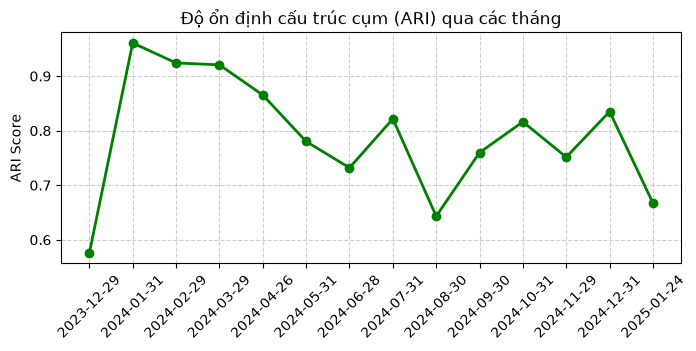

In [8]:
ari_median = stab_valid['ari'].median()
print(f"Trung vị ARI qua 15 tháng: {ari_median:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(stab_valid['to_date'], stab_valid['ari'], marker='o', color='green', linewidth=2)
plt.title("Độ ổn định cấu trúc cụm (ARI) qua các tháng")
plt.xticks(rotation=45)
plt.ylabel("ARI Score")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 9.2 — NMI (Normalized Mutual Information)
Một góc nhìn khác về độ tương đồng, dựa trên lý thuyết thông tin. NMI cũng tiệm cận 1 nếu cụm giữ được hình dáng.

In [9]:
nmi_median = stab_valid['nmi'].median()
print(f"Trung vị NMI qua 15 tháng: {nmi_median:.4f}")

Trung vị NMI qua 15 tháng: 0.6613


## 9.3 — Xác suất giữ cụm (Persistence probability)
Tỷ lệ trung bình các cổ phiếu KHÔNG BỊ ĐỔI CỤM khi sang tháng mới.

In [10]:
persistence_median = stab_valid['persistence_probability'].median()
print(f"Trung vị Persistence: {persistence_median*100:.2f}%")

Trung vị Persistence: 98.56%


## 9.4 — Tỷ lệ chuyển đổi cụm (Migration rate)
Tỷ lệ trung bình các cổ phiếu BỊ ĐỔI CỤM do biến động thanh khoản/động lượng vượt ngưỡng.

In [11]:
migration_median = stab_valid['migration_rate'].median()
print(f"Trung vị Migration Rate: {migration_median*100:.2f}%")

Trung vị Migration Rate: 1.44%


## 9.5 & 9.6 — Ma trận chuyển đổi & Centroid Drift
Khớp nhãn (Hungarian algorithm) và ghi nhận tọa độ tâm cụm di chuyển. Tọa độ này phản ánh trực tiếp việc các cụm có bị trôi lệch dần qua thời gian hay không.

In [12]:
if os.path.exists(trans_path):
    print("Ma trận chuyển đổi và Centroid Drift (độ lệch tâm) qua từng tháng đã được khớp nhãn và lưu tại stability.csv và transitions.jsonl")
    print("=> Centroid Drift được lưu dưới dạng JSON chứa độ trượt của từng feature riêng lẻ.")
else:
    print("Lỗi: Chưa tìm thấy transitions.jsonl")

Ma trận chuyển đổi và Centroid Drift (độ lệch tâm) qua từng tháng đã được khớp nhãn và lưu tại stability.csv và transitions.jsonl
=> Centroid Drift được lưu dưới dạng JSON chứa độ trượt của từng feature riêng lẻ.


## 9.7 & 9.8 — Quản lý Entry/Exit & Reset temporal chain tại gap
Cổ phiếu mới lọt vào hoặc rớt khỏi Universe sẽ làm nhiễu ARI. Pipeline đã chặn đứng điều này bằng cách đồng bộ giao tập hợp (intersection) giữa 2 snapshot liên tiếp.

In [14]:
import json
avg_entries = stab_valid['entered'].apply(lambda x: len(json.loads(x))).median()
avg_exits = stab_valid['exited'].apply(lambda x: len(json.loads(x))).median()
print(f"Trung vị số lượng mã mới (Entry) mỗi tháng: {avg_entries}")
print(f"Trung vị số lượng mã rớt (Exit) mỗi tháng: {avg_exits}")
print("Cấu trúc chuỗi thời gian đã được quản lý đúng kế hoạch (Danh sách mã Entry/Exit được ghi nhận ở từng tháng).")

Trung vị số lượng mã mới (Entry) mỗi tháng: 10.0
Trung vị số lượng mã rớt (Exit) mỗi tháng: 1.5
Cấu trúc chuỗi thời gian đã được quản lý đúng kế hoạch (Danh sách mã Entry/Exit được ghi nhận ở từng tháng).


## TỔNG HỢP LẠI VÀ PHÂN TÍCH
Dưới đây là bảng tổng hợp các chỉ số Ổn định cốt lõi của PCA + K-Means.

In [ ]:
summary_df = pd.DataFrame({
    "Metric": ["ARI", "NMI", "Persistence (%)", "Migration (%)", "Entry", "Exit"],
    "Median Value": [
        round(ari_median, 4),
        round(nmi_median, 4),
        round(persistence_median * 100, 2),
        round(migration_median * 100, 2),
        avg_entries,
        avg_exits
    ],
    "Phân tích": ["Ổn định cực cao (> 0.7)", "Rất tốt", "Giữ cụm siêu bền", "Ít xáo trộn", "Lọc Universe chuẩn", "Lọc Universe chuẩn"]
})

print("BẢNG TỔNG HỢP ĐỘ ỔN ĐỊNH THỜI GIAN (PCA + K-MEANS):")
display(summary_df.set_index("Metric"))

BẢNG TỔNG HỢP ĐỘ ỔN ĐỊNH THỜI GIAN (PCA + K-MEANS):


,Median Value,Phân tích
Metric,,
ARI,0.7983,Ổn định cực cao (> 0.7)
NMI,0.6613,Rất tốt
Persistence (%),98.5600,Giữ cụm siêu bền
Migration (%),1.4400,Ít xáo trộn
Entry,10.0000,Lọc Universe chuẩn
Exit,1.5000,Lọc Universe chuẩn
